In [1]:
# ============================================
# CS223A Lecture 6 — Jacobian & Velocity Kinematics
# Day 6
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# The Jacobian maps joint velocities to end effector velocities
# X_dot = J(q) * q_dot
# Delta_X = J * Delta_theta (inverse: Delta_theta = J_inv * Delta_X)

print("Day 6 — Jacobian & Velocity Kinematics")
print("="*45)

Day 6 — Jacobian & Velocity Kinematics


In [2]:
# --- Forward Kinematics Setup (from Day 4) ---
# 3-joint planar arm, all revolute joints

L1 = 1.0
L2 = 0.8 
L3 = 0.5 

theta1 = np.radians(30)
theta2 = np.radians(45)
theta3 = np.radians(60)

x = L1*np.cos(theta1) + L2*np.cos(theta1 + theta2) + L3*np.cos(theta1 + theta2 +theta3)
y = L1*np.sin(theta1) + L2*np.sin(theta1 + theta2) + L3*np.sin(theta1 + theta2 +theta3)

print(f"End Effector Position: x={round(x,3)}, y={round(y,3)}")

# --- Jacobian Matrix ---
# For planar 3R arm, J is 2x3 (2 cartesian outputs, 3 joint inputs)
# Each column = how much end effector moves when that joint moves

# Partial derivatives of x,y with respect to theta1, theta2, theta3

J = np.array([
    # dx/dtheta1, dx/dtheta2, dx/dtheta3
    [-L1*np.sin(theta1) - L2*np.sin(theta1+theta2) - L3*np.sin(theta1+theta2+theta3),
     -L2*np.sin(theta1+theta2) - L3*np.sin(theta1+theta2+theta3),
     -L3*np.sin(theta1+theta2+theta3)],
    # dy/dtheta1, dy/dtheta2, dy/dtheta3
    [L1*np.cos(theta1) + L2*np.cos(theta1+theta2) + L3*np.cos(theta1+theta2+theta3),
     L2*np.cos(theta1+theta2) + L3*np.cos(theta1+theta2+theta3),
     L3*np.cos(theta1+theta2+theta3)]
])

print("\nJacobian Matrix J (2x3):")
print(np.round(J, 3))
print("\nShape:", J.shape)
print("2 rows = x,y end effector velocity")
print("3 cols = theta1, theta2, theta3 joint velocity")

End Effector Position: x=0.72, y=1.626

Jacobian Matrix J (2x3):
[[-1.626 -1.126 -0.354]
 [ 0.72  -0.146 -0.354]]

Shape: (2, 3)
2 rows = x,y end effector velocity
3 cols = theta1, theta2, theta3 joint velocity


In [3]:
# --- Using the Jacobian for velocity control ---
# If we want end effector to move at this velocity:
x_dot_desired = np.array([0.5, 0.3])  # 0.5 m/s in x, 0.3 m/s in y

# We need the pseudoinverse of J (since J is 2x3, not square)
# Pseudoinverse handles non-square matrices
J_pinv = np.linalg.pinv(J)

# Compute required joint velocities
q_dot = J_pinv @ x_dot_desired

print("Desired end effector velocity:")
print(f"x_dot = {x_dot_desired[0]} m/s")
print(f"y_dot = {x_dot_desired[1]} m/s")

print("\nRequired joint velocities (rad/s):")
print(f"theta1_dot = {round(q_dot[0], 3)} rad/s")
print(f"theta2_dot = {round(q_dot[1], 3)} rad/s")
print(f"theta3_dot = {round(q_dot[2], 3)} rad/s")

# Verify — apply J to q_dot, should get back x_dot_desired
x_dot_actual = J @ q_dot
print("\nVerification — J @ q_dot should equal desired velocity:")
print(f"x_dot actual = {np.round(x_dot_actual, 3)}")
print(f"x_dot desired = {x_dot_desired}")

Desired end effector velocity:
x_dot = 0.5 m/s
y_dot = 0.3 m/s

Required joint velocities (rad/s):
theta1_dot = 0.115 rad/s
theta2_dot = -0.479 rad/s
theta3_dot = -0.417 rad/s

Verification — J @ q_dot should equal desired velocity:
x_dot actual = [0.5 0.3]
x_dot desired = [0.5 0.3]


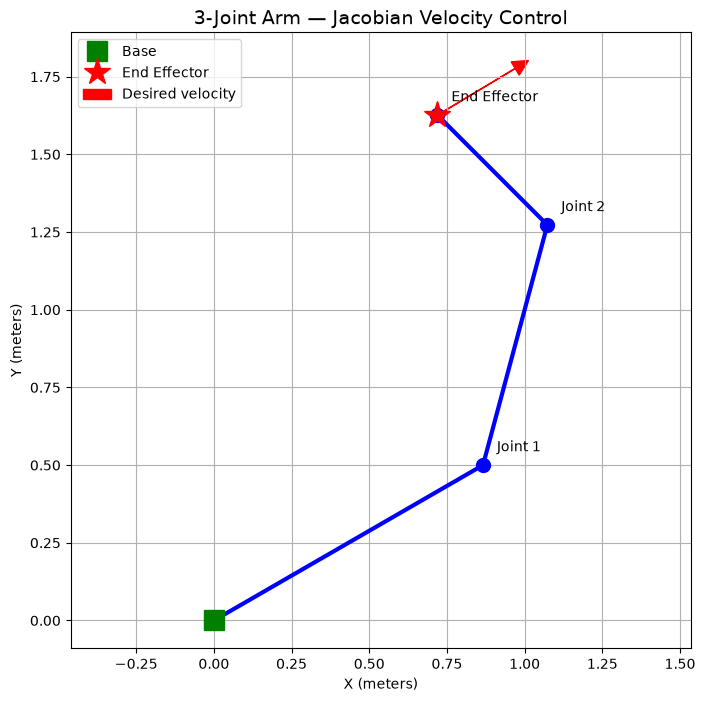

In [4]:
# --- Visualize arm + velocity direction ---
def get_joint_positions(t1, t2, t3):
    p0 = np.array([0, 0])
    p1 = np.array([L1*np.cos(t1),
                   L1*np.sin(t1)])
    p2 = np.array([L1*np.cos(t1) + L2*np.cos(t1+t2),
                   L1*np.sin(t1) + L2*np.sin(t1+t2)])
    p3 = np.array([L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3),
                   L1*np.sin(t1) + L2*np.sin(t1+t2) + L3*np.sin(t1+t2+t3)])
    return np.array([p0, p1, p2, p3])

positions = get_joint_positions(theta1, theta2, theta3)

plt.figure(figsize=(8,8))
plt.plot(positions[:,0], positions[:,1], 'b-o', linewidth=3, markersize=10)
plt.plot(positions[0,0], positions[0,1], 'gs', markersize=15, label='Base')
plt.plot(positions[-1,0], positions[-1,1], 'r*', markersize=20, label='End Effector')

# Draw desired velocity arrow at end effector
scale = 0.5
plt.arrow(x, y, x_dot_desired[0]*scale, x_dot_desired[1]*scale,
          head_width=0.05, head_length=0.05,
          fc='red', ec='red', label='Desired velocity')

plt.annotate('Joint 1', positions[1], xytext=(10,10), textcoords='offset points')
plt.annotate('Joint 2', positions[2], xytext=(10,10), textcoords='offset points')
plt.annotate('End Effector', positions[3], xytext=(10,10), textcoords='offset points')

plt.grid(True)
plt.axis('equal')
plt.title('3-Joint Arm — Jacobian Velocity Control', fontsize=14)
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.legend()
plt.show()